In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import numpy as np
import seaborn as sns
sns.set_theme(style="ticks", palette="pastel")

df=pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-10-27/wind-turbine.csv')
df.tail(2)

,objectid,province_territory,project_name,total_project_capacity_mw,turbine_identifier,turbine_number_in_project,turbine_rated_capacity_k_w,rotor_diameter_m,hub_height_m,manufacturer,model,commissioning_date,latitude,longitude,notes
6696,6697,Yukon,Haeckel Hill,0.81,HAH1,1/2,150.0,23.0,30.0,Bonus,B23/150,1993,60.748818,-135.229274,NaN
6697,6698,Yukon,Haeckel Hill,0.81,HAH2,2/2,660.0,47.0,37.0,Vestas,V47,2000,60.748678,-135.231748,NaN


In [3]:
# handle overlapping years
df['commissioning_date'] = df['commissioning_date'].map({'2000/2001': '2000', 
                                                       '2001/2003': '2001'})

[Text(0, 0, 'Ontario'),
 Text(1, 0, 'Quebec'),
 Text(2, 0, 'Alberta'),
 Text(3, 0, 'British Columbia'),
 Text(4, 0, 'Nova Scotia'),
 Text(5, 0, 'New Brunswick'),
 Text(6, 0, 'Manitoba'),
 Text(7, 0, 'Saskatchewan'),
 Text(8, 0, 'Prince Edward Island'),
 Text(9, 0, 'Newfoundland and Labrador'),
 Text(10, 0, 'Northwest Territories'),
 Text(11, 0, 'Yukon')]

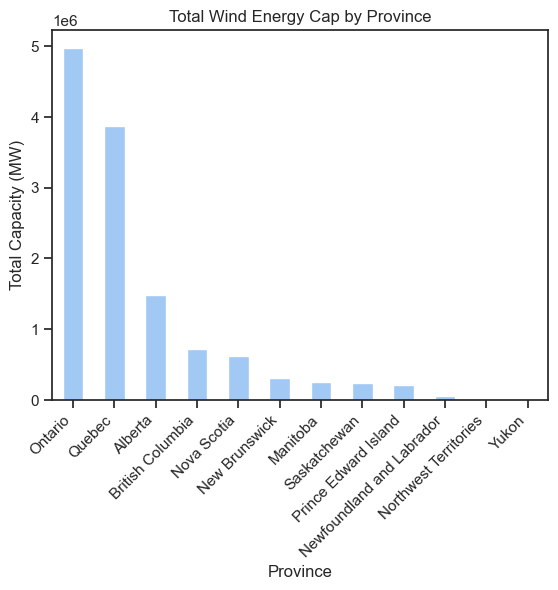

In [ ]:
# province level views
# total capacity by province
cap_by_prov=df.groupby(['province_territory']).sum()['turbine_rated_capacity_k_w']
ax=cap_by_prov.sort_values(ascending=False).plot(kind='bar')
# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Province')
ax.set_ylabel('Total Capacity (MW)')
ax.set_title('Total Wind Energy Cap by Province')
#ax.set_xticks(x)
#ax.set_xticklabels(labels)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
#ax.legend()

<Axes: xlabel='province_territory'>

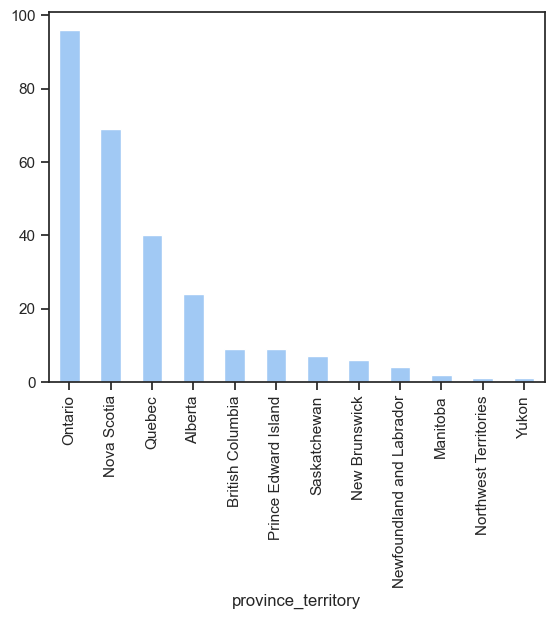

In [ ]:
# number of projects by province
proj_by_prov=df.groupby(['province_territory']).nunique()['project_name']
proj_by_prov.sort_values(ascending=False).plot(kind='bar')

<Axes: >

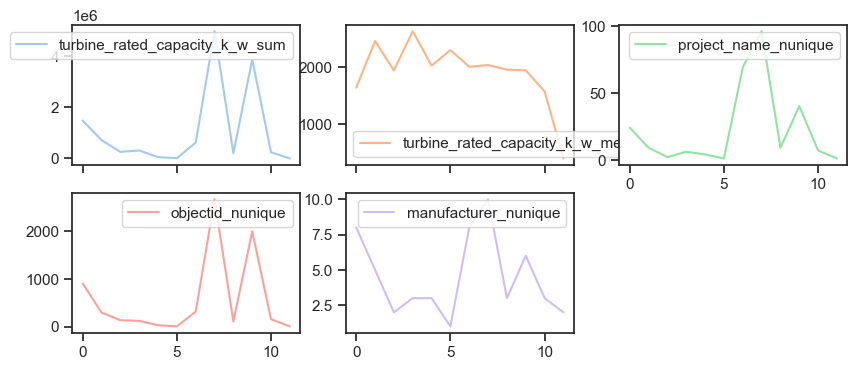

In [9]:
prov_grouping = df.groupby(['province_territory']).agg({
    'turbine_rated_capacity_k_w': ['sum', 'mean'],
    'project_name': 'nunique',
    'objectid': 'nunique',
    'manufacturer': 'nunique'
})

# flatten columns
prov_grouping.columns = ['_'.join(col) for col in prov_grouping.columns]
prov_grouping = prov_grouping.reset_index()

# plots
prov_grouping.plot(subplots=True, layout=(2, 3), figsize=(12, 8))

prov_grouping['turbine_rated_capacity_k_w_sum'] \
    .sort_values(ascending=False) \
    .plot(kind='bar', figsize=(10, 4))

C:\Users\vivek\AppData\Local\Temp\ipykernel_11628\1633192091.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
C:\Users\vivek\AppData\Local\Temp\ipykernel_11628\1633192091.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
C:\Users\vivek\AppData\Local\Temp\ipykernel_11628\1633192091.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')


"\n# Num of turbines x Total capacity - scatter plot of provinces\nax=sns.scatterplot(data=prov_grouping, \n                 x=prov_grouping.iloc[:,0], \n                 y=prov_grouping.iloc[:,3],hue=prov_grouping.index, \n                 ax=axs[2])                   \nax.set(xlabel='Total Turbine Cap (MW)', ylabel='Number of Turbines', title='Number of Turbines x Total Cap')\n"

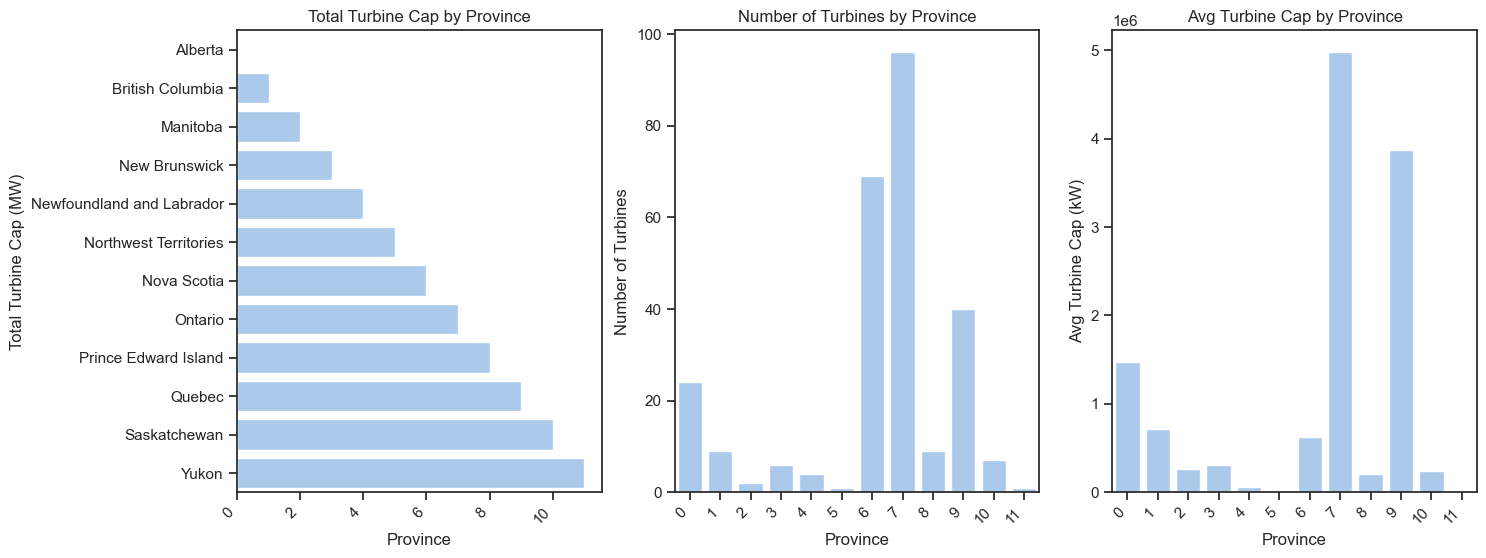

In [ ]:
# PLOTTING PROVINCE DATA
# plotting multiple plots together
plt.rcParams['figure.figsize']=16,6   # default: 6.4, 4.8
fig, axs = plt.subplots(ncols=3) # nrows=2,

# Chart - avg turbine capacity by province
ax = sns.barplot(data=prov_grouping, 
                 x=prov_grouping.index, 
                 y=prov_grouping.iloc[:,1],ax=axs[2]) # ,ax=axs[0,0]
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
ax.set(xlabel='Province', ylabel='Avg Turbine Cap (kW)', title='Avg Turbine Cap by Province')

# Chart - total turbine capacity by province
ax = sns.barplot(data=prov_grouping, 
                 x=prov_grouping.index, 
                 y=prov_grouping.iloc[:,0],ax=axs[0])
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
ax.set(xlabel='Province', ylabel='Total Turbine Cap (MW)', title='Total Turbine Cap by Province')
'''
## figure out this error
# NotImplementedError: Index._join_level on non-unique index is not implemented
# Chart - number of projects by province
ax = sns.barplot(data=prov_grouping, 
                 x=prov_grouping.index, 
                 y=prov_grouping.iloc[:,2],ax=axs[1]) # prov_grouping['project_name']['nunique']
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
ax.set(xlabel='Province', ylabel='Number of Projects', title='Number of Projects by Province')
'''
# Chart - number of turbines by province
ax = sns.barplot(data=prov_grouping, 
                 x=prov_grouping.index, 
                 y=prov_grouping.iloc[:,3],ax=axs[1])
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
ax.set(xlabel='Province', ylabel='Number of Turbines', title='Number of Turbines by Province')
'''
# Num of turbines x Total capacity - scatter plot of provinces
ax=sns.scatterplot(data=prov_grouping, 
                 x=prov_grouping.iloc[:,0], 
                 y=prov_grouping.iloc[:,3],hue=prov_grouping.index, 
                 ax=axs[2])                   
ax.set(xlabel='Total Turbine Cap (MW)', ylabel='Number of Turbines', title='Number of Turbines x Total Cap')
'''

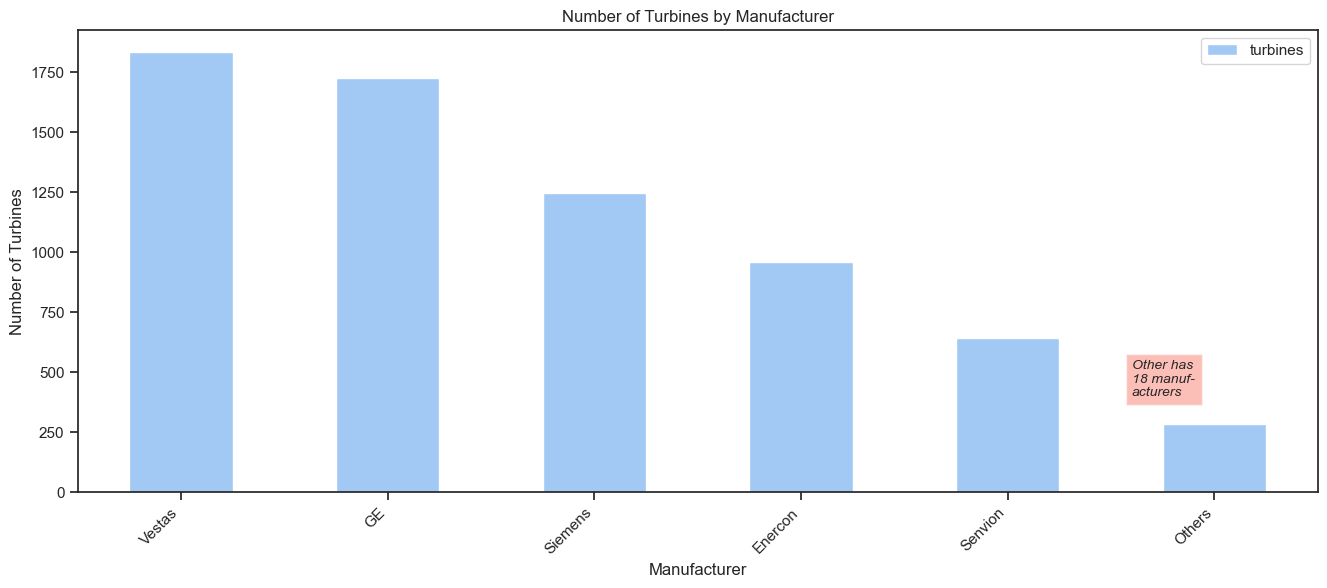

In [12]:
# manufacturer level views
# number of turbines by manufacturer
turb_by_manuf=df.groupby(['manufacturer']).count()['objectid'].sort_values(ascending=False)
turb_by_manuf[turb_by_manuf>500]
turb_by_manuf= pd.DataFrame({'manufacturer': ['Vestas', 'GE', 'Siemens', 'Enercon', 'Senvion', 'Others'],
                    'turbines': [1834,1725,1248,960,643,286]})

ax=turb_by_manuf.plot(kind='bar')
ax.set_xticklabels(turb_by_manuf.manufacturer, rotation=45, horizontalalignment='right')
ax.text(4.6, 400, 'Other has \n18 manuf-\nacturers', fontsize=10, style='italic',
        bbox={'facecolor': 'salmon', 'alpha': 0.5, 'pad': 4})
ax.set(xlabel='Manufacturer', ylabel='Number of Turbines', title='Number of Turbines by Manufacturer')
plt.xticks(rotation=45, horizontalalignment="right")


manuf_grouping=df.groupby(['manufacturer']).agg({
    'turbine_rated_capacity_k_w':['sum','mean'],  # total and avg capacity of turbines installed by manufacturer
    'project_name':'nunique', # number of projects by manufacturer
    'province_territory':'nunique'}) # number of provinces manufacturer operates in 

In [ ]:
# commmission date level views
# projects started by commissioning_date
proj_by_comm_dt=df.groupby(['commissioning_date']).nunique()['project_name']
ax=proj_by_comm_dt.plot(kind='bar')
ax.text(9.6, 30, '2010-16 seems\nto be a period\nof boom', fontsize=10, style='italic',
        bbox={'facecolor': 'salmon', 'alpha': 0.5, 'pad': 4})
ax.set(xlabel='Year', ylabel='Number of Projects', title='Number of Projects by Year')

In [ ]:
# turbines installed by commissioning_date
turb_by_comm_dt=df.groupby(['commissioning_date']).count()['objectid']
ax=turb_by_comm_dt.plot(kind='bar')
ax.text(9.6, 800, '2010-16 seems\nto be a period\nof boom', fontsize=10, style='italic',
        bbox={'facecolor': 'salmon', 'alpha': 0.5, 'pad': 4})
ax.set(xlabel='Year', ylabel='Number of Turbines', title='Number of Turbines by Year')

[Text(0.5, 0, 'Boxplot'),
 Text(0, 0.5, 'Number of Turbines'),
 Text(0.5, 1.0, 'Number of Turbines by Project')]

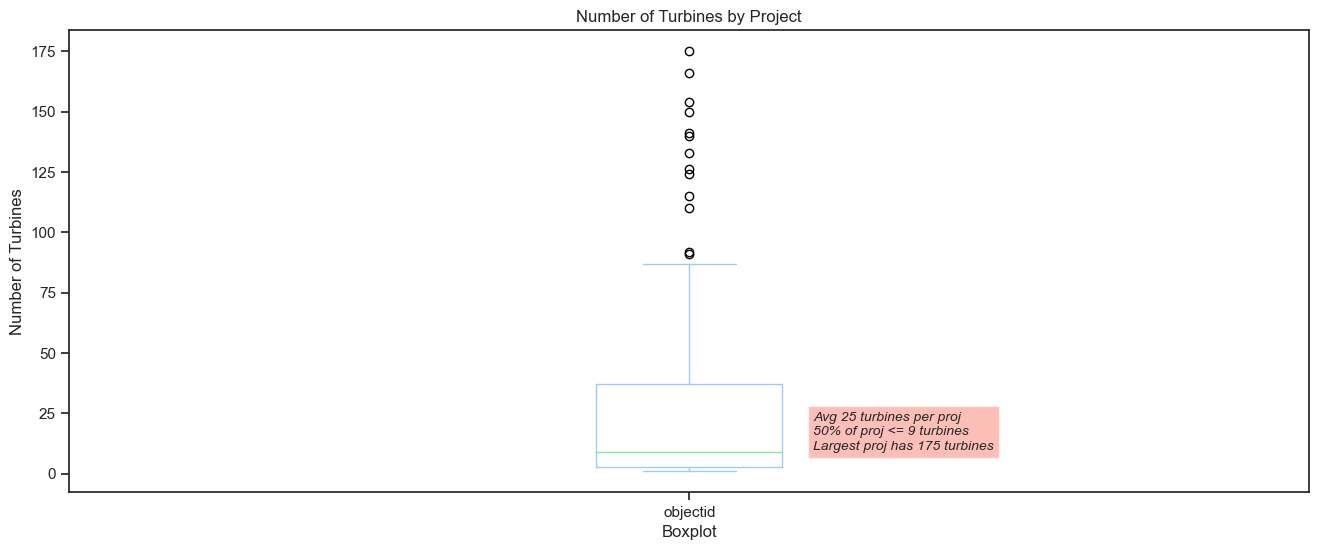

In [22]:
# turbine level views
# top 10 projects by number of turbines
top_proj_by_num_turb=df.groupby(['project_name']).count()['objectid']
top_proj_by_num_turb.sort_values(ascending=False).describe()
top_proj_by_num_turb.sort_values(ascending=False).median()

ax=top_proj_by_num_turb.plot(kind='box')
ax.text(1.1, 10, 'Avg 25 turbines per proj\n50% of proj <= 9 turbines\nLargest proj has 175 turbines', fontsize=10, style='italic',
        bbox={'facecolor': 'salmon', 'alpha': 0.5, 'pad': 4})
ax.set(xlabel='Boxplot', ylabel='Number of Turbines', title='Number of Turbines by Project')


[Text(0.5, 0, 'Histogram'),
 Text(0, 0.5, 'Number of Turbines'),
 Text(0.5, 1.0, 'Histogram of Number of Turbines by Project')]

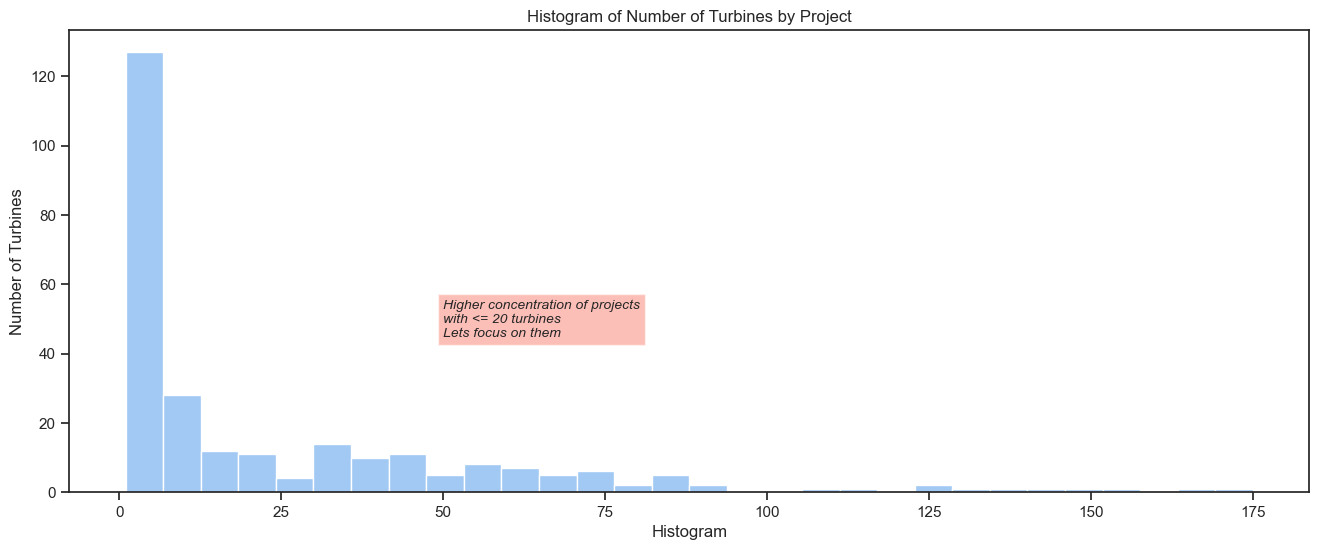

In [23]:
ax=top_proj_by_num_turb.plot(kind='hist', bins=30)
ax.text(50, 45, 'Higher concentration of projects\nwith <= 20 turbines\nLets focus on them', fontsize=10, style='italic',
        bbox={'facecolor': 'salmon', 'alpha': 0.5, 'pad': 4})
ax.set(xlabel='Histogram', ylabel='Number of Turbines', title='Histogram of Number of Turbines by Project')


[Text(0.5, 0, 'Histogram'),
 Text(0, 0.5, 'Number of Turbines'),
 Text(0.5, 1.0, 'Histogram of Number of Turbines by Project (<20 turbines)')]

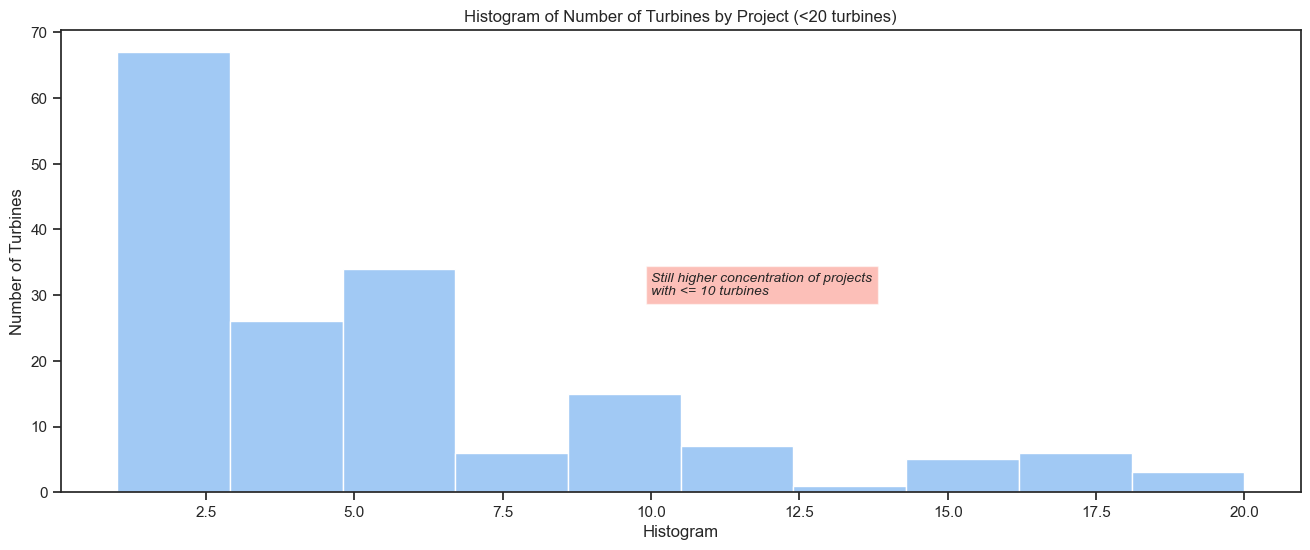

In [24]:
ax=top_proj_by_num_turb[top_proj_by_num_turb<=20].plot(kind='hist')
ax.text(10, 30, 'Still higher concentration of projects\nwith <= 10 turbines', fontsize=10, style='italic',
        bbox={'facecolor': 'salmon', 'alpha': 0.5, 'pad': 4})
ax.set(xlabel='Histogram', ylabel='Number of Turbines', title='Histogram of Number of Turbines by Project (<20 turbines)')

In [25]:
top_proj_by_num_turb.sort_values(ascending=False).head(10)

project_name
Rivière-du-Moulin             175
Blackspring Ridge Wind        166
Seigneurie de Beaupré         154
Lac Alfred                    150
Gros-Morne                    141
K2 Wind Power Facility        140
Melancthon                    133
Prince Wind Energy Project    126
South Kent Wind Farm          124
McBride Lake                  115
Name: objectid, dtype: int64

In [ ]:
# top 10 projects by capacity
top_proj_by_cap=df.groupby(['project_name']).sum()['turbine_rated_capacity_k_w']
top_proj_by_cap.sort_values(ascending=False).head(10)

In [27]:
# correlation between turbine rated capacity and diameter/height of turbine


# geographical data

In [ ]:
# geographical data
lat/lon to plot projects 
lat/lon to plot turbine volume


import geopandas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings

warnings.filterwarnings('ignore')

%matplotlib inline

geopandas.datasets.available

world = geopandas.read_file(geopandas.datasets.get_path("naturalearth_lowres"))
print("Geometry Column Name : ", world.geometry.name)
print("Dataset Size : ", world.shape)
world.head()


nybb = geopandas.read_file(geopandas.datasets.get_path("nybb"))
nybb.head()

world.plot(figsize=(12,8));

with plt.style.context(("seaborn", "ggplot")):
    nybb.plot(figsize=(12,8), color="white", edgecolor="grey");


world_happiness = pd.read_csv("world_happiness_2019.csv")
print("Dataset Size : ",world_happiness.shape)
world_happiness.head()


##################################

Adding latitude and longitudes to a map in Python involves two processes:
- import data file containing latitude and longitude features
- import map image as .shp file


import numpy as np
import pandas as pd


# import libraries
import geopandas as gpd
from shapely.geometry import Point, Polygon
import matplotlib.pyplot as plt
# import street map
street_map = gpd.read_file('lpr_000b16a_e.shp')

# designate coordinate system
crs = {'init':'espc:4326'}
# zip x and y coordinates into single feature
geometry = [Point(xy) for xy in zip(df['longitude'], df['latitude'])]
# create GeoPandas dataframe
geo_df = gpd.GeoDataFrame(df, crs = crs, geometry = geometry)


# using altair for plotting

In [ ]:
import altair as alt

# option 1
alt.data_transformers.disable_max_rows() # Disabling MaxRowsError
# option 2
alt.data_transformers.enable('json') # save data to a local filesystem and reference the data by file path
alt.data_transformers.enable('csv')
# option 3
# pip install altair_data_server
# serve your data from a local threaded server to avoid writing datasets to disk
alt.data_transformers.enable('data_server') # enable the data transformer

import pandas as pd

df=pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-10-27/wind-turbine.csv')
df.columns
df.head(2)

# bar chart
d1=df.groupby(['province_territory']).sum()['turbine_rated_capacity_k_w']
d1=pd.DataFrame(d1) # Convert Series to DataFrame
d1.reset_index(level=0, inplace=True) # Convert Index to Column
alt.Chart(d1).mark_bar().encode(
    x='province_territory',
    y='turbine_rated_capacity_k_w'
)

# stacked bar chart
d11=df.groupby(['manufacturer','province_territory']).sum()['turbine_rated_capacity_k_w']
d11=pd.DataFrame(d11) # Convert Series to DataFrame
d11.reset_index(level=0, inplace=True) # Convert Index to Column
d11.reset_index(level=0, inplace=True) # Reset twice because there were two indexes in the DataFrame
alt.Chart(d11).mark_bar().encode(
    y='province_territory',
    x='turbine_rated_capacity_k_w',
    color='manufacturer'
)

# heatmap
d2=df.groupby(['province_territory','manufacturer']).count()['objectid']
d2=pd.DataFrame(d2) # Convert Series to DataFrame
d2.reset_index(level=0, inplace=True) # Convert Index to Column
d2.reset_index(level=0, inplace=True) # Reset twice because there were two indexes in the DataFrame
alt.Chart(d2).mark_rect().encode(
    x='province_territory',
    y='manufacturer',
    color='objectid'
)

# histogram
d3=df.groupby(['project_name']).nunique()['objectid']
d3=pd.DataFrame(d3) # Convert Series to DataFrame
d3.reset_index(level=0, inplace=True) # Convert Index to Column
alt.Chart(d3).mark_bar().encode(
    alt.X('objectid', bin=True),
    y='count()',
)

# line plot
d4=df.groupby(['commissioning_date','province_territory']).nunique()['objectid']
d4=pd.DataFrame(d4) # Convert Series to DataFrame
d4.reset_index(level=0, inplace=True) # Convert Index to Column
d4.reset_index(level=0, inplace=True) # Reset twice because there were two indexes in the DataFrame
alt.Chart(d4).mark_line().encode(
    x='commissioning_date',
    y='objectid',
    color='province_territory'
)

# scatter plot
d5=df.groupby(['project_name','rotor_diameter_m','hub_height_m']).nunique()['objectid']
d5=pd.DataFrame(d5) # Convert Series to DataFrame
d5.reset_index(level=0, inplace=True) # Convert Index to Column
d5.reset_index(level=0, inplace=True) # Reset thrice because there were three indexes in the DataFrame
d5.reset_index(level=0, inplace=True) # Reset thrice because there were three indexes in the DataFrame
alt.Chart(d5).mark_circle(size=60).encode(
    x='rotor_diameter_m',
    y='hub_height_m',
    color='objectid',
    tooltip=['project_name', 'rotor_diameter_m', 'hub_height_m', 'objectid']
).interactive()

# stacked area chart - not sure if this is showing what i intended to show
d6=df.groupby(['commissioning_date','province_territory']).sum()['turbine_rated_capacity_k_w']
d6=pd.DataFrame(d6) # Convert Series to DataFrame
d6['turbine_rated_capacity_k_w_cumulative']=d6['turbine_rated_capacity_k_w'].cumsum()
d6.reset_index(level=0, inplace=True) # Convert Index to Column
d6.reset_index(level=0, inplace=True) # Reset twice because there were two indexes in the DataFrame
alt.Chart(d6).mark_area().encode(
    x="commissioning_date:T",
    y="turbine_rated_capacity_k_w_cumulative:Q",
    color="province_territory:N"
)

# strip plot
d7=df.groupby(['province_territory','hub_height_m']).nunique()['objectid']
d7=pd.DataFrame(d7) # Convert Series to DataFrame
d7.reset_index(level=0, inplace=True) # Convert Index to Column
d7.reset_index(level=0, inplace=True) # Reset twice because there were two indexes in the DataFrame
alt.Chart(d7).mark_tick().encode(
    x='province_territory:N',
    y='hub_height_m:Q',
    tooltip=['province_territory', 'hub_height_m', 'objectid']
).interactive()




